# installing dependencies

In [ ]:
!pip install -q emoji
!pip install -q PyArabic
!pip install -q arabert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 18.0 MB/s eta 0:00:00


In [ ]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA A100-SXM4-40GB
Sat Apr  4 15:24:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             42W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        

#Creating training datasets

In [ ]:
import pandas as pd
import numpy as np
from typing import List
from tqdm import tqdm_notebook as tqdm
from sklearn.model_selection import train_test_split

This custom dataset class will help us hold our datasets in a structred manner.
It's not necessary to use it with your own data

In [ ]:
class CustomDataset:
    def __init__(
        self,
        name: str,
        train: List[pd.DataFrame],
        val: List[pd.DataFrame],
        test: List[pd.DataFrame],
        label_list: List[str],
    ):
        """Class to hold and structure datasets.

        Args:

        name (str): holds the name of the dataset so we can select it later
        train (List[pd.DataFrame]): holds training pandas dataframe with 2 columns ["text","label"]
        val (List[pd.DataFrame]): holds validation pandas dataframe with 2 columns ["text","label"]
        test (List[pd.DataFrame]): holds testing pandas dataframe with 2 columns ["text","label"]
        label_list (List[str]): holds the list  of labels
        """
        self.name = name
        self.train = train
        self.val = val
        self.test = test
        self.label_list = label_list

In [ ]:
# This will hold all the downloaded and structred datasets
all_datasets= []
DATA_COLUMN = "text"
LABEL_COLUMN = "Final Label"

You can choose which ever dataset you like or use your own.
At this stage we don't do any preprocessing on the text, this is done later when loading the text.

## Climate Data

In [ ]:
data = pd.read_excel('All Climate Change Data - All Related.xlsx')

data.drop_duplicates(subset='text', inplace = True)
data.dropna(inplace = True, subset='text')
data.reset_index(drop=True, inplace = True)

data = data[['text', 'Final Label']]
data['Final Label'] = data['Final Label'].str.lower()
data.columns = [DATA_COLUMN, LABEL_COLUMN]
print(data[LABEL_COLUMN].value_counts())

Final Label
neutral     10307
negative     8140
positive     5510
Name: count, dtype: int64


In [ ]:
data.shape

(23957, 2)

In [ ]:
print(data[LABEL_COLUMN].value_counts())

Final Label
neutral     10307
negative     8140
positive     5510
Name: count, dtype: int64


In [ ]:
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace(r'[^\w\s]+', '')
data[DATA_COLUMN] = data[DATA_COLUMN].str.replace("\s+", " ", regex=True)

In [ ]:
import string
import re

arabic_punctuations = '''`÷×؛<>_()*&^%][ـ،/:"؟.,'{}~¦+|!”…“–ـ'''
english_punctuations = string.punctuation
punctuations_list = arabic_punctuations + english_punctuations

def normalize_arabic(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("گ", "ك", text)
    return text

data[DATA_COLUMN] = data[DATA_COLUMN].apply(normalize_arabic)

data.head()

,text,Final Label
0,هذه ال٢.٥٪ لا تنطلق الى الفضاء الكوني فتحتبس و...,negative
1,#عاجل | ادارة الكوارث والطوارئ التركية: ازالة ...,neutral
2,RT @USUN: عُقد في مالطا هذا الاسبوع اول اجتماع...,neutral
3,رغم ارتفاع درجات الحرارة واشعة الشمس اللاهبة و...,positive
4,قبل ايام تم استضافتي لتسجيل بودكاست بحكم اختصا...,neutral


In [ ]:
def data_cleaning(text):
    """Clean and preprocess text data.
    Args:
        text (pd.Series): A pandas Series containing text data to be cleaned.
    Returns:
        pd.Series: A pandas Series with the cleaned text data.

    Cleaning Steps:
    - Removes emojis and special characters like '\x89Û_', '&amp', etc.
    - Replaces consecutive dots with an empty string.
    - Removes '#' symbol from text.
    - Removes user names starting with '@'.
    - Removes URLs starting with 'http' or 'https'.
    - Remove diacritics.
    - Remove English.
    - Removes extra whitespaces between words.

    """
    clean = text
    # Replace consecutive dots with an empty string
    pattern = re.compile('\\.+?(?=\B|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Replace '\x89Û_' with a whitespace
    pattern = re.compile('\x89Û_')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Replace newline characters with a whitespace
    pattern = re.compile('\\n')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=' '))
    # Remove '#' symbol from text
    clean = clean.apply(lambda r: r.replace('#', ''))
    # Remove '_' symbol from text
    pattern = re.compile('_')
    clean = clean.apply(lambda r: re.sub(pattern, ' ', r))
    # Replace user names with '@'
    pattern = re.compile('@[a-zA-Z0-9\_]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='@'))
    # Remove URLs
    pattern = re.compile('https?\S+(?=\s|$)')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl='www'))
    # Remove emojis
    clean = clean.apply(lambda r: emoji.replace_emoji(r, replace=""))
    # Remove diacritics
    clean = clean.apply(lambda r: araby.strip_diacritics(r))
    # Remove English
    pattern = re.compile(r'[a-zA-Z]+')
    clean = clean.apply(lambda r: re.sub(pattern, string=r, repl=''))
    # Remove extra whitespaces
    clean = clean.apply(lambda r: ' '.join(r.split()))  # Remove extra whitespaces between words

    return clean

In [ ]:
import pyarabic.araby as araby
import emoji
import re

data[DATA_COLUMN] = data_cleaning(data[DATA_COLUMN])

In [ ]:
def remove_specific_term(text):
  cleaned_text = re.sub(r'\bpictwitercom\w*\b', '', text)
  cleaned_text = cleaned_text.strip() # Remove any leading or trailing whitespace
  return cleaned_text

data[DATA_COLUMN] = data[DATA_COLUMN].apply(remove_specific_term)

In [ ]:
def remove_ids(text):
  return text.split("—")[0].strip()

data[DATA_COLUMN] = data[DATA_COLUMN].apply(remove_ids)

In [ ]:
data.dropna(inplace = True)
data = data.drop_duplicates(subset = DATA_COLUMN)

In [ ]:
indecies = pd.read_csv('Train-Val-Test-Indecies-Climate.csv')

# Clean and convert to integer index arrays
test = data.loc[indecies['test'].dropna().astype(int).values]
train1 = data.loc[indecies['train'].dropna().astype(int).values]
val1 = data.loc[indecies['val'].dropna().astype(int).values]

In [ ]:
train1.shape

(16769, 2)

# Load ASAD data

In [ ]:
asad = pd.read_csv('train_all.csv')
asad = asad.rename(columns={'Text':DATA_COLUMN, 'sentiment':LABEL_COLUMN})
asad[LABEL_COLUMN] = asad[LABEL_COLUMN]

asad[DATA_COLUMN] = asad[DATA_COLUMN].str.replace(r'[^\w\s]+', '')
asad[DATA_COLUMN] = asad[DATA_COLUMN].str.replace("\s+", " ", regex=True)

asad[DATA_COLUMN] = asad[DATA_COLUMN].apply(normalize_arabic)

asad[DATA_COLUMN] = data_cleaning(asad[DATA_COLUMN])
asad[DATA_COLUMN] = asad[DATA_COLUMN].apply(remove_ids)

In [ ]:
ind = pd.read_excel('/content/Used ASAD For Training.xlsx')

previous_trained = asad.loc[ind['Unnamed: 0'].values]
previous_trained = previous_trained[[DATA_COLUMN, LABEL_COLUMN]]

previous_trained.columns = [DATA_COLUMN, LABEL_COLUMN]
previous_trained = previous_trained.reset_index(drop = True)
print(previous_trained[LABEL_COLUMN].value_counts())

Final Label
neutral     16289
negative     3890
positive     3778
Name: count, dtype: int64


In [ ]:
previous_trained.head()

,text,Final Label
0,ياحبي المغرور ياللي دفاك شعور رد القمر للنور و...,positive
1,من شدة حبك له تتمنى لو ان الاسى ياكلك باكملك و...,positive
2,يالليل يا جامع على الود قلبين,neutral
3,حفلة اكثر من رائعة ستقام في جوهرة جدة كبيرة وج...,positive
4,لا امتلك تعريفا واضحا للاهاب بس طالما جامعة ال...,neutral


In [ ]:
new = asad.drop(index=ind['Unnamed: 0'].values)
print(new.shape[0])
new.dropna(inplace = True)
new.drop_duplicates(subset = DATA_COLUMN, inplace = True)
print(new.shape[0])

31043
30145


In [ ]:
remove, additional = train_test_split(new,
                               test_size=14034,
                               stratify=new[LABEL_COLUMN],
                               random_state=42)

train2, temp = train_test_split(additional,
                               test_size=0.3,
                               stratify=additional[LABEL_COLUMN],
                               random_state=42)

val2, test2 = train_test_split(temp,
                             test_size=0.5,
                             stratify=temp[LABEL_COLUMN],
                             random_state=42)

In [ ]:
train = pd.concat([train1, train2])
val = pd.concat([val1, val2])

In [ ]:
label_list = ['negative', 'neutral', 'positive']

data = CustomDataset("Climate", train, val, test, label_list)
all_datasets.append(data)

#Trainer

Start the training procedure

In [ ]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import copy

from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                          AutoTokenizer, BertTokenizer, Trainer,
                          TrainingArguments)
from transformers.data.processors.utils import InputFeatures

List all the datasets we have

In [ ]:
for x in all_datasets:
  print(x.name)

Climate


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# select a dataset
dataset_name = 'Climate'
model_name = 'aubmindlab/bert-base-arabertv02-twitter'

In [ ]:
for d in all_datasets:
  if d.name==dataset_name:
    selected_dataset = copy.deepcopy(d)
    print('Dataset found')
    break

Dataset found


Create and apply preprocessing using the AraBERT processor

In [ ]:
arabic_prep = ArabertPreprocessor(model_name)

selected_dataset.train[DATA_COLUMN] = selected_dataset.train[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.val[DATA_COLUMN] = selected_dataset.val[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.test[DATA_COLUMN] = selected_dataset.test[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))

In [ ]:
# Sanity check on the dataset
list(selected_dataset.train[DATA_COLUMN][0:10])

['الانسان المثقف والانسان العادي الانسان المثقف محمل حالو هموم الدني ومفكر حالو بيقدر يسكر ثقب الاوزون ، الانسان العادي ولا على بالو عايش ومرتاح',
 'اعتدال ونشاط في سرعة الرياح الشمالية الغربية مع غبار مثار في المناطق البرية والمكشوفة اليوم الاربعاء وغدا الخميس وارتفاع الامواج في البحر والطقس جاف مع ارتفاع درجات الحرارة العظمى نهار اليوم في شمال شرق السعودية والكويت',
 'ابناء ورجالات تبوك بتكاتفهم وتكاتف مؤسسات المجتمع المدني باستطاعتهم جعل تبوك الورد اسم على مسمى تطوع ابناء تبوك لمكافحة التصحر',
 'كونا : مسؤول بيئي عربي : مؤتمر التصحر بانقرة يسلط الضوء على تخفيف تدهور الاراضي',
 'قضية تغير المناخ وقضية الاوبئة هما الاولتان عالميا بالتبادل فى اهتمام الدول الكبرى الراعية لارتفاع درجة الحرارة والراعية للتلوث والراعية للحرب الفيروسية',
 'الصين تواجه ازمة الطاقة بقرارات صعبة : منها رفع اسعار الطاقة ولكن اهم قرار : ارسال الاوامر الى مناجم الفحم " انتجوا ما تستطيعون انتاجه من الفحم " يعنى توجه الصين لحل ازمةالطاقة : انتاج مزيد من الفحم وليذهب المناخ وتغيراته الى الجحيم وتعد الصين من اكبر دول

Now we need to check the tokenized sentence length to decide on the maximum sentence length value

In [ ]:
tok = AutoTokenizer.from_pretrained(model_name)

Training Sentence Lengths: 


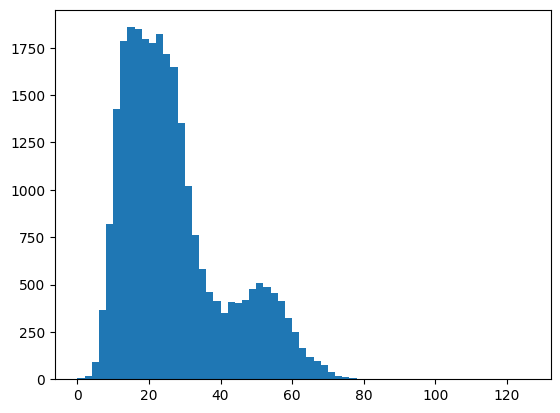

Testing Sentence Lengths: 


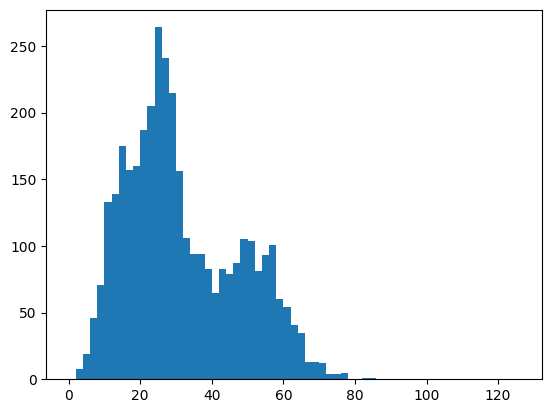

In [ ]:
print("Training Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.train[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

print("Testing Sentence Lengths: ")
plt.hist([ len(tok.tokenize(sentence)) for sentence in selected_dataset.test[DATA_COLUMN].to_list()],bins=range(0,128,2))
plt.show()

Let's select 100 as our maximum sentence length, and check how many sequences will be truncated

In [ ]:
max_len = 128

In [ ]:
print("Truncated training sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

print("Truncated testing sequences: ", sum([len(tok.tokenize(sentence)) > max_len for sentence in selected_dataset.test[DATA_COLUMN].to_list()]))

Truncated training sequences:  0
Truncated testing sequences:  0


8 out of ~4000 for testing isn't bad

Now let's create a classification dataset to load the data

In [ ]:
class ClassificationDataset(Dataset):
    def __init__(self, text, target, model_name, max_len, label_map):
      super(ClassificationDataset).__init__()
      """
      Args:
      text (List[str]): List of the training text
      target (List[str]): List of the training labels
      tokenizer_name (str): The tokenizer name (same as model_name).
      max_len (int): Maximum sentence length
      label_map (Dict[str,int]): A dictionary that maps the class labels to integer
      """
      self.text = text
      self.target = target
      self.tokenizer_name = model_name
      self.tokenizer = AutoTokenizer.from_pretrained(model_name)
      self.max_len = max_len
      self.label_map = label_map


    def __len__(self):
      return len(self.text)

    def __getitem__(self,item):
      text = str(self.text[item])
      text = " ".join(text.split())

      inputs = self.tokenizer(
          text,
          max_length=self.max_len,
          padding='max_length',
          truncation=True
      )
      return InputFeatures(**inputs,label=self.label_map[self.target[item]])

In [ ]:
label_map = { v:index for index, v in enumerate(selected_dataset.label_list) }
print(label_map)

train_dataset = ClassificationDataset(
    selected_dataset.train[DATA_COLUMN].to_list(),
    selected_dataset.train[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )
val_dataset = ClassificationDataset(
    selected_dataset.val[DATA_COLUMN].to_list(),
    selected_dataset.val[LABEL_COLUMN].to_list(),
    model_name,
    max_len,
    label_map
  )

{'negative': 0, 'neutral': 1, 'positive': 2}


Check the dataset output

In [ ]:
print(next(iter(train_dataset)))

InputFeatures(input_ids=[2, 4199, 8088, 49075, 10850, 4199, 8088, 27938, 1050, 185, 15903, 37901, 12208, 435, 1050, 185, 1268, 2394, 1287, 435, 41400, 32254, 319, 103, 4199, 10850, 662, 323, 15665, 17906, 16708, 571, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], attention_mask=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], token_type_ids=[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

Create a function that return a pretrained model ready to do classification

In [ ]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, return_dict=True, num_labels=len(label_map))

Define whatever metric you want here

In [ ]:
def compute_metrics(p): #p should be of type EvalPrediction
  preds = np.argmax(p.predictions, axis=1)
  assert len(preds) == len(p.label_ids)
  macro_f1 = f1_score(p.label_ids,preds,average='macro')
  macro_precision = precision_score(p.label_ids,preds,average='macro')
  macro_recall = recall_score(p.label_ids,preds,average='macro')
  acc = accuracy_score(p.label_ids,preds)
  return {
      'macro_f1' : macro_f1,
      'macro_precision' : macro_precision,
      'macro_recall' : macro_recall,
      'accuracy': acc
  }

In [ ]:
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark = False

#Regular Training

Define our training parameters.
Check the TrainingArguments documentation for more options https://huggingface.co/transformers/main_classes/trainer.html#trainingarguments

In [ ]:
training_args = TrainingArguments(
    output_dir= "./train",
    adam_epsilon = 1e-8,
    learning_rate = 2e-5,
    fp16 = False, # enable this when using V100 or T4 GPU
    per_device_train_batch_size = 32, # up to 64 on 16GB with max len of 128
    per_device_eval_batch_size = 128,
    gradient_accumulation_steps = 2, # use this to scale batch size without needing more memory
    num_train_epochs= 3,
    warmup_ratio = 0,
    do_eval = True,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    load_best_model_at_end = True, # this allows to automatically get the best model at the end based on whatever metric we want
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    seed = 25,
    report_to = 'none'
  )

set_seed(training_args.seed)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Create the trainer

In [ ]:
trainer = Trainer(
    model = model_init(),
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
#start the training
trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1,Macro Precision,Macro Recall,Accuracy
1,No log,0.561401,0.750547,0.744683,0.761711,0.755571
2,1.134243,0.549539,0.752580,0.746353,0.759929,0.758730
3,0.905740,0.573280,0.751605,0.743328,0.762025,0.757501


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1248, training_loss=0.9771320514189892, metrics={'train_runtime': 422.1253, 'train_samples_per_second': 188.987, 'train_steps_per_second': 2.956, 'total_flos': 5247534003167232.0, 'train_loss': 0.9771320514189892, 'epoch': 3.0})

Save the model, the tokenizer and the config

In [ ]:
inv_label_map = inv_label_map = { v:k for k, v in label_map.items()}
print(inv_label_map)
trainer.model.config.label2id = label_map
trainer.model.config.id2label = inv_label_map
trainer.save_model("COMBINED_dir")
train_dataset.tokenizer.save_pretrained("COMBINED_dir")

{0: 'negative', 1: 'neutral', 2: 'positive'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('COMBINED_dir/tokenizer_config.json', 'COMBINED_dir/tokenizer.json')

## predict using the saved model

In [ ]:
from transformers import pipeline
import more_itertools

In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = selected_dataset.test[DATA_COLUMN].values

In [ ]:
pipe = pipeline("sentiment-analysis", model=f"COMBINED_dir", device=0, return_all_scores =True, max_length=max_len, truncation=True)
preds = []
for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_df[f'preds'] = preds

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_2152/298879525.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference


0it [00:00, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
final_pred = []
for prediction in pred_df['preds']:
  final_pred.append(prediction['label'])

pred_df[f'Final Prediction'] = final_pred
pred_df[f'Final Prediction'].value_counts()

,count
Final Prediction,
neutral,1395
negative,1273
positive,926


In [ ]:
print(classification_report(selected_dataset.test[LABEL_COLUMN],pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7527    0.7952    0.7734      1221
     neutral     0.7348    0.6701    0.7009      1546
    positive     0.7494    0.8102    0.7786       827

    accuracy                         0.7449      3594
   macro avg     0.7456    0.7585    0.7510      3594
weighted avg     0.7442    0.7449    0.7434      3594



# Pred on Asad

In [ ]:
remove.shape

(16111, 3)

In [ ]:
indecies = pd.read_csv('Train-Val-Test-Indecies-Climate-ASAD.csv')

# Clean and convert to integer index arrays
test = previous_trained.loc[indecies['test'].dropna().astype(int).values]

In [ ]:
pred_asad = pd.DataFrame()
pred_asad['text'] = test['text'].values

pipe = pipeline("sentiment-analysis", model=f"COMBINED_dir", device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_asad['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_asad[f'preds'] = preds

final_pred = []
for prediction in pred_asad['preds']:
  final_pred.append(prediction['label'])

pred_asad[f'Final Prediction'] = final_pred
pred_asad[f'Final Prediction'].value_counts()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_2152/51063295.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_asad['text']), 32)): # batching for faster inference


0it [00:00, ?it/s]

,count
Final Prediction,
neutral,2500
negative,577
positive,517


In [2]:
print('Macro Average Scores')
pre = precision_score(test['Final Label'],pred_asad['Final Prediction'], average = 'macro')
print(f'Precision = {pre:.3f}')
recall = recall_score(test['Final Label'],pred_asad['Final Prediction'], average = 'macro')
print(f'Recall = {recall:.3f}')
f1 = f1_score(test['Final Label'],pred_asad['Final Prediction'], average = 'macro')
print(f'F1 score = {f1:.3f}')

print('Weighted Average Scores')
pre = precision_score(test['Final Label'],pred_asad['Final Prediction'], average = 'weighted')
print(f'Precision = {pre:.3f}')
recall = recall_score(test['Final Label'],pred_asad['Final Prediction'], average = 'weighted')
print(f'Recall = {recall:.3f}')
f1 = f1_score(test['Final Label'],pred_asad['Final Prediction'], average = 'weighted')
print(f'F1 score = {f1:.3f}')

Macro Average Scores
Precision = 0.727
Recall = 0.728
F1 score = 0.727
Weighted Average Scores
Precision = 0.796
Recall = 0.795
F1 score = 0.795


# ASTD

In [ ]:
import pandas as pd

# Read the .txt file (comma, tab, or custom-delimited)
df = pd.read_csv('Tweets.txt', delimiter='\t', header=None, names=['text', 'Label'])  # Change delimiter if needed
df.head()

,text,Label
0,بعد استقالة رئيس #المحكمة_الدستورية ننتظر استق...,OBJ
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,POS
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,NEG
3,#الحرية_والعدالة | شاهد الآن: #ليلة_الاتحادية ...,OBJ
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,NEUTRAL


In [ ]:
df = df[df['Label']!='OBJ']
df['Label'] = df['Label'].map({
    'NEG': 'negative',
    'NEUTRAL': 'neutral',
    'POS': 'positive'
})
df.head()

,text,Label
1,أهنئ الدكتور أحمد جمال الدين، القيادي بحزب مصر...,positive
2,البرادعي يستقوى بامريكا مرةاخرى و يرسل عصام ال...,negative
4,الوالدة لو اقولها بخاطري حشيشة تضحك بس من اقول...,neutral
5,#انتخبوا_العرص #انتخبوا_البرص #مرسى_رئيسى #اين...,neutral
6,امير عيد هو اللي فعلا يتقال عليه ستريكر صريح #...,positive


In [ ]:
df['text'] = df['text'].str.replace(r'[^\w\s]+', '')
df['text'] = df['text'].str.replace("\s+", " ", regex=True)

df['text'] = df['text'].apply(normalize_arabic)

df['text'] = data_cleaning(df['text'])
df['text'] = df['text'].apply(remove_ids)

df.dropna(inplace = True)
df = df.drop_duplicates(subset = 'text')

In [ ]:
pred_df = pd.DataFrame()
pred_df['text'] = df['text'].values

pipe = pipeline("sentiment-analysis", model=f"COMBINED_dir", device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_df[f'preds'] = preds

final_pred = []
for prediction in pred_df['preds']:
  final_pred.append(prediction['label'])

pred_df[f'Final Prediction'] = final_pred
pred_df[f'Final Prediction'].value_counts()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_2152/2029480847.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_df['text']), 32)): # batching for faster inference


0it [00:00, ?it/s]

,count
Final Prediction,
neutral,1625
negative,1212
positive,386


In [ ]:
print(classification_report(df['Label'],pred_df['Final Prediction'], digits=4))

              precision    recall  f1-score   support

    negative     0.7861    0.5935    0.6764      1641
     neutral     0.3534    0.6770    0.4644       805
    positive     0.8167    0.4646    0.5923       777

    accuracy                         0.5833      3223
   macro avg     0.6521    0.5784    0.5777      3223
weighted avg     0.6854    0.5833    0.6032      3223



# SemEval

In [ ]:
semeval = pd.read_csv('SemEval2017-task4-train.subtask-A.arabic.txt', delimiter='\t', header=None, names=['id', 'sentiment', 'text'])
semeval = semeval[['text', 'sentiment']]

semeval['sentiment'] = semeval['sentiment'].map({
    'negative': 'negative',
    'neutral': 'neutral',
    'positive': 'positive'
})
semeval.head()

,text,sentiment
0,إجبار أبل على التعاون على فك شفرة اجهزتها http...,positive
1,RT @20fourMedia: #غوغل تتحدى أبل وأمازون بأجهز...,positive
2,جوجل تنافس أبل وسامسونج بهاتف جديد https://t.c...,positive
3,رئيس شركة أبل: الواقع المعزز سيصبح أهم من الطع...,positive
4,ساعة أبل في الأسواق مرة أخرى https://t.co/dY2x...,neutral


In [ ]:
semeval['text'] = semeval['text'].str.replace(r'[^\w\s]+', '')
semeval['text'] = semeval['text'].str.replace("\s+", " ", regex=True)

semeval['text'] = semeval['text'].apply(normalize_arabic)

semeval['text'] = data_cleaning(semeval['text'])
semeval['text'] = semeval['text'].apply(remove_ids)

semeval.dropna(inplace = True)
semeval = semeval.drop_duplicates(subset = 'text')

In [ ]:
pred_semeval = pd.DataFrame()
pred_semeval['text'] = semeval['text'].values

pipe = pipeline("sentiment-analysis", model=f"COMBINED_dir", device=0, return_all_scores =True, max_length=max_len, truncation=True)

preds = []
for s in tqdm(more_itertools.chunked(list(pred_semeval['text']), 32)): # batching for faster inference
    preds.extend(pipe(s))
pred_semeval[f'preds'] = preds

final_pred = []
for prediction in pred_semeval['preds']:
  final_pred.append(prediction['label'])

pred_semeval[f'Final Prediction'] = final_pred
pred_semeval[f'Final Prediction'].value_counts()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_2152/3596742932.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_semeval['text']), 32)): # batching for faster inference


0it [00:00, ?it/s]

,count
Final Prediction,
neutral,2430
negative,578
positive,273


In [3]:
print('Macro Average Scores')
pre = precision_score(semeval['sentiment'],pred_semeval['Final Prediction'], average = 'macro')
print(f'Precision = {pre:.3f}')
recall = recall_score(semeval['sentiment'],pred_semeval['Final Prediction'], average = 'macro')
print(f'Recall = {recall:.3f}')
f1 = f1_score(semeval['sentiment'],pred_semeval['Final Prediction'], average = 'macro')
print(f'F1 score = {f1:.3f}')

print('Weighted Average Scores')
pre = precision_score(semeval['sentiment'],pred_semeval['Final Prediction'], average = 'weighted')
print(f'Precision = {pre:.3f}')
recall = recall_score(semeval['sentiment'],pred_semeval['Final Prediction'], average = 'weighted')
print(f'Recall = {recall:.3f}')
f1 = f1_score(semeval['sentiment'],pred_semeval['Final Prediction'], average = 'weighted')
print(f'F1 score = {f1:.3f}')

Macro Average Scores
Precision = 0.64
Recall = 0.519
F1 score = 0.524
Weighted Average Scores
Precision = 0.638
Recall = 0.59
F1 score = 0.561
